# Hardware ASCON-128 Power Trace Acquisition for TVLA

This notebook performs the **online phase** of the side-channel analysis workflow targeting a **1st-order masked hardware implementation of ASCON-128** on the CW305 FPGA board.

## Objective

The primary goal is to acquire power traces to perform a **Test Vector Leakage Assessment (TVLA)**, also known as a "fixed-vs-random" test. This assessment is used to determine if the implementation leaks information that could be exploited by a side-channel attack, despite the presence of masking countermeasures.

## Capture Methodology

* **Fixed vs. Random Nonce:** In ASCON, the Nonce is a critical entry point for the initialization phase. For TVLA, we keep the Key and Plaintext constant while interleaving traces where the **Nonce is fixed** with traces where the **Nonce is randomly generated**.
* **Interleaving:** The choice between a fixed or random nonce is made non-deterministically for every encryption. This prevents environmental drift (like thermal changes) from being mistaken for algorithmic leakage.
* **Instrumentation:** Traces are captured using a high-resolution Picoscope, synchronized with the FPGA's internal trigger.

## Targeted Implementation

* **Cipher:** ASCON-128 (Authenticated Encryption with Associated Data).
* **Countermeasure:** 1st-order Domain Oriented (Boolean) Masking.
* **Platform:** OpenHW Group `x-heep` / CW305 FPGA.


## Data Storage

Traces and metadata (labels, nonces, and keys) are stored in an **HDF5 (`.h5`)** format. 

In [15]:
import os
import sys
import time
import io                  
import contextlib   
from tqdm import tqdm
import h5py
from pathlib import Path
import numpy as np
from tqdm.notebook import tnrange
import matplotlib.pyplot as plt  

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories ( sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [2]:
def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent
    raise RuntimeError("Could not find project root. Please ensure you are inside the Side-Channel-Dojo repository.")

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# Paths
ASCON_PY_DIR = DOJO_ROOT / "sw" / "ciphers" / "ASCON_python"
SCA_DIR      = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR       = DOJO_ROOT / "hw"

# Output directories
TRACESET_DIR = DOJO_ROOT / "sw" / "traceset" / "ASCON" / "hw"
BASE_PLOT_DIR = DOJO_ROOT / "sw" / "sca_scripts" / "ASCON" / "hw" / "plot"

TRACESET_DIR.mkdir(parents=True, exist_ok=True)
BASE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ASCON_PY_DIR))
sys.path.insert(0, str(SCA_DIR))

In [3]:
# Import custom modules
global PS5000aWrapper, CW305Wrapper, ascon_encrypt
from pico_api import PS5000aWrapper
from CW305_ascon_api import CW305Wrapper
from golden_model_ascon import ascon_encrypt

# Configuration

In [10]:
# ---------------------------------------------------------------------------
# Helper for pretty yes/no printing
# ---------------------------------------------------------------------------
def _yn(flag: bool) -> str:
    return "yes" if flag else "no"

# ---------------------------------------------------------------------------
# Configuration Parameters
# ---------------------------------------------------------------------------

# TVLA Settings
n_fixed = 100
n_random = 100
n_trc = n_fixed + n_random

# Bitstream path (As specified for ASCON Masked)
bitstream_path = HW_DIR / "fpga" / "bitstream" / "ascon" / "ascon_masked" / "cw305_top.bit"
bitstream = str(bitstream_path)

# Picoscope Configuration (As specified: 22us, 2200 samples)
obs_time = 22e-6
nSamples = 2200

# Flags
save_dataset = False
traces_overlapped_plot = True
save_plot = True
debug = True  # Set to True to see status bits and match validations


# Output Paths
TRACESET_FILE = TRACESET_DIR / f"ascon_masked_{n_trc // 1000}k_tvla.h5"
PLOT_DIR = BASE_PLOT_DIR / "ascon_masked"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------
print("\n================ ASCON HW TVLA CAPTURE CONFIGURATION ================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  Cipher            : ASCON-128")
print(f"  Countermeasure    : 1st-order Masking")
print()
print("Paths")
print(f"  Bitstream         : {bitstream_path}")
print(f"  HW traces file    : {TRACESET_FILE}")
print(f"  SCA traces dir    : {TRACESET_DIR}")
print(f"  Plot dir          : {PLOT_DIR}")
print()
print("Scope Setup")
print(f"  Observation Time  : {obs_time} s")
print(f"  Samples           : {nSamples}")
print()
print("Online phase")
print(f"  Number of traces  : {n_trc} ({n_fixed} fixed, {n_random} random)")
print(f"  Save dataset      : {_yn(save_dataset)}")
print(f"  Overlapped plot   : {_yn(traces_overlapped_plot)}")
print(f"  Save plot         : {_yn(save_plot)}")
print("=====================================================================\n")


================ ASCON HW TVLA CAPTURE CONFIGURATION ================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Cipher            : ASCON-128
  Countermeasure    : 1st-order Masking

Paths
  Bitstream         : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/fpga/bitstream/ascon/ascon_masked/cw305_top.bit
  HW traces file    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/hw/ascon_masked_0k_tvla.h5
  SCA traces dir    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/hw
  Plot dir          : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/ASCON/hw/plot/ascon_masked

Scope Setup
  Observation Time  : 2.2e-05 s
  Samples           : 2200

Online phase
  Number of traces  : 200 (100 fixed, 100 random)
  Save dataset      : no
  Overlapped plot   : yes
  Save plot         : yes



# Board preparation

In [13]:
def prepare_board(bitstream, obs_time):
    try:
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        ps.scope_setup(obs_time=obs_time, nSamples=2200)
        cw305 = CW305Wrapper(ps, bitstream, True)
        return ps, cw305
    except Exception as e:
        print(f"Error during board preparation: {e}")
        raise
    
# ---------------------------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------------------------
def ascon_encrypt_quiet(*args, **kwargs):
    """Silences the print output from the golden model."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        out = ascon_encrypt(*args, **kwargs)
    return out, buf.getvalue()


## Online phase : ASCON HW power traces capture

The parameters below dictate the TVLA capture set. Collect 10,000 fixed traces and 10,000 random traces (20,000 total).

In [14]:
# ---------------------------------------------------------------------------
# TVLA Random Interleaving & Data Setup
labels = np.array([0] * n_fixed + [1] * n_random, dtype=np.uint8)
np.random.shuffle(labels)

key = bytes.fromhex("0f0e0d0c0b0a09080706050403020100")
fixed_nonce = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
aad = b"\x00" * 16 
msg = b"\x00" * 16 

ps, cw305 = prepare_board(bitstream, obs_time)
n_samples = getattr(ps, 'nSamples', None) or ps.get_nSamples()

# ---------------------------------------------------------------------------
# Trace Capture & Validation
# ---------------------------------------------------------------------------
try:
    cw305.reset_ascon_core()
    cw305.set_key(key)
    cw305.set_initial_data(aad, msg)
    traces = np.empty((n_trc, n_samples), dtype=float)
    nonces = np.empty((n_trc, 16), dtype=np.uint8)
    
    mismatches = 0
    print("[ONLINE] Starting ASCON Masked TVLA capture...")
    for i in tqdm(range(n_trc)):
        current_nonce = fixed_nonce if labels[i] == 0 else os.urandom(16)
        cw305.set_nonce(current_nonce)
        
        cw305.reset_ascon_core()
        status_start = cw305.read_fpga(cw305.REG_CRYPT_STATUS, 1)[0]
        
        if debug:
            tqdm.write(f"[DEBUG] Status before trigger: {status_start:08b}")
        # Hardware Capture
        trace = cw305.capture_ascon_trace() 
        hw_ct, hw_tag = cw305.read_results()
        
        traces[i] = trace
        nonces[i] = list(current_nonce)
        
        # Software Validation
        sw_all, gm_log = ascon_encrypt_quiet(key, current_nonce, aad, msg, variant="Ascon-AEAD128")
        sw_tag = sw_all[-16:]
        sw_ct = sw_all[:-16]
        
        if hw_ct != sw_ct or hw_tag != sw_tag:
            mismatches += 1
            tqdm.write("❌ Mismatch!")
            tqdm.write(f"  HW CT : {hw_ct.hex()}")
            tqdm.write(f"  SW CT : {sw_ct.hex()}")
            tqdm.write(f"  HW TAG: {hw_tag.hex()}")
            tqdm.write(f"  SW TAG: {sw_tag.hex()}")
            tqdm.write("— Golden trace —")
            tqdm.write(gm_log)
        else:
            if debug:
                tqdm.write(f"✅ Match  CT={hw_ct.hex()}  TAG={hw_tag.hex()}")
            
    print(f"\nCapture complete. Total Mismatches: {mismatches}/{n_trc}")
    # -----------------------------------------------------------------------
    # Dataset Saving
    # -----------------------------------------------------------------------
    if save_dataset:
        with h5py.File(TRACESET_FILE, "w") as f:
            f.create_dataset("traces", data=traces)
            f.create_dataset("labels", data=labels)
            f.create_dataset("nonces", data=nonces)
            f.attrs["bitstream"] = bitstream
            f.attrs["mismatches"] = mismatches 
            
        print(f"Saved to {TRACESET_FILE}")
finally:
    print("Cleaning up hardware connections...")
    cw305.dis()
    ps.dis()

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.11.5086
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : 11768/0019
CalDate                       : 24Feb25
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0


(ChipWhisperer Target WARNING|File CW305.py:345) Verilog defines not found in default location (/home/mattia-mirigaldi/.pyenv/versions/cw/lib/python3.9/site-packages/chipwhisperer/../../hardware/victims/cw305_artixtarget/fpga/common/cw305_defines.v).
Using defines from CW305.py.If this isn't what you want, either add 'slurp=False', or provide defines location in 'defines_files'


True
[ONLINE] Starting ASCON Masked TVLA capture...


  0%|          | 0/200 [00:00<?, ?it/s]

[DEBUG] Status before trigger: 00000001


...

✅ Match  CT=83f742e4fa293c0b207a638aa0be8e91  TAG=b8f544e285393aeb62397954b1b7cc44
[DEBUG] Status before trigger: 00000001
✅ Match  CT=83f742e4fa293c0b207a638aa0be8e91  TAG=b8f544e285393aeb62397954b1b7cc44
[DEBUG] Status before trigger: 00000001
✅ Match  CT=a90c1e1e5054b56525c50c69ecfd81f2  TAG=06b6c80b7ff79638f78d689624dc77d2
[DEBUG] Status before trigger: 00000001
✅ Match  CT=83f742e4fa293c0b207a638aa0be8e91  TAG=b8f544e285393aeb62397954b1b7cc44
[DEBUG] Status before trigger: 00000001


 99%|█████████▉| 198/200 [00:10<00:00, 20.48it/s]

✅ Match  CT=83f742e4fa293c0b207a638aa0be8e91  TAG=b8f544e285393aeb62397954b1b7cc44
[DEBUG] Status before trigger: 00000001
✅ Match  CT=2de9b4749f37c3e13e927c45887761b8  TAG=d8a8b199a2951145561d5e89abf58d20
[DEBUG] Status before trigger: 00000001
✅ Match  CT=ce41870e7bc8fd6f98db372f90e78167  TAG=c065b8ec98c03546655e5bc58609ef44
[DEBUG] Status before trigger: 00000001
✅ Match  CT=205ca47680fb7c4f66209e262c2b9f49  TAG=9834ca0641c309b122293a17f400d5a4
[DEBUG] Status before trigger: 00000001
✅ Match  CT=de12d2e14cd6bd27ced8f2c5f6582585  TAG=b35cdd562e17b19b5309f7540d8062df


100%|██████████| 200/200 [00:10<00:00, 18.92it/s]


[DEBUG] Status before trigger: 00000001
✅ Match  CT=46425ca4611d63d5dffac8bed6d64269  TAG=dafa4225d932830f4bdd4b1b24a017e5
[DEBUG] Status before trigger: 00000001
✅ Match  CT=625b01d862bf32e318f99aedbd4dfc88  TAG=413a8953cc312aca4563032555fd70c8

Capture complete. Total Mismatches: 0/200
Cleaning up hardware connections...


# Plot


Generating overlapped plot...


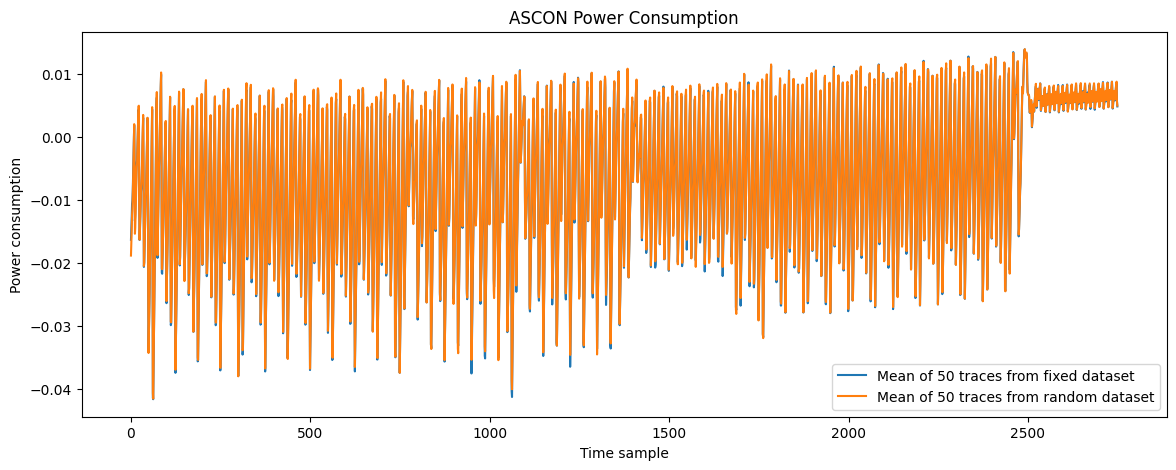

In [16]:
# -----------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------
if traces_overlapped_plot:
    print("\nGenerating overlapped plot...")
    # Extract the first 50 traces for each dataset
    fix_idx = np.where(labels == 0)[0][:50]
    rand_idx = np.where(labels == 1)[0][:50]    
    traces_fix = traces[fix_idx]
    traces_rand = traces[rand_idx]

    plt.figure(figsize=(14,5))
    plt.plot(np.mean(traces_fix, axis=0), label='Mean of 50 traces from fixed dataset')
    plt.plot(np.mean(traces_rand, axis=0), label='Mean of 50 traces from random dataset')
    plt.title('ASCON Power Consumption')
    plt.xlabel('Time sample')
    plt.ylabel('Power consumption')
    plt.legend()
            
    #if save_plot:
    #    plot_file = PLOT_DIR / "ascon_overlapped_traces.png"
    #    plt.savefig(plot_file)
    #    print(f"Plot saved to {plot_file}")